# 03 — Trening baseline modela (M0: c-ResUnet)

Treniramo c-ResUnet **bez** attention gate-ova (ELU aktivacija).
Reprodukcija baseline-a iz Morelli & Clissa (2021) bez weight mapa.

**Pipeline:**
1. Učitavanje podataka (crops za train, full-size za val)
2. Definicija i inspekcija modela
3. Trening sa weighted BCE, early stopping, LR scheduler
4. Vizualizacija loss krivih
5. Threshold tuning na validaciji
6. Čuvanje modela i predikcija za Deo C

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src import config
from src.data_loading import make_dataset
from src.models import build_model
from src.train import (
    get_device, train_model, find_best_threshold,
    save_model, save_predictions, count_parameters,
)

## 1. Učitavanje podataka

In [3]:
device = get_device()
print(f"Device: {device}")

Device: mps


In [ ]:
train_ds = make_dataset(split="train", form="crops", augment=True)
val_ds   = make_dataset(split="val",   form="full",  augment=False)
test_ds  = make_dataset(split="test",  form="full",  augment=False)

print(f"Train: {len(train_ds)} crop-ova")
print(f"Val:   {len(val_ds)} celih slika")
print(f"Test:  {len(test_ds)} celih slika")

Train: 2040 crop-ova
Val:   43 celih slika
Test:  70 celih slika


In [6]:
BATCH_SIZE = config.BATCH_SIZE_BASELINE

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=1,          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=0)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batch-eva: {len(train_loader)}")

Batch size: 8
Train batch-eva: 255


## 2. Model

In [7]:
model = build_model(attention=False, activation="elu")
model = model.to(device)
model

CResUnet(
  (init_conv): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (enc1): ResBlock(
    (conv_branch): Sequential(
      (0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (1): ELU(alpha=1.0, inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (4): ELU(alpha=1.0, inplace=True)
      (5): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (shortcut): Identity()
  )
  (enc1_5x5): Sequential(
    (0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): ELU(alpha=1.0, inplace=True)
    (2): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ResBlock(
   

In [8]:
count_parameters(model)

  init_conv: 48 parametara
  enc1: 4,672 parametara
  enc1_5x5: 6,432 parametara
  pool1: 0 parametara
  enc2: 14,432 parametara
  pool2: 0 parametara
  enc3: 57,536 parametara
  pool3: 0 parametara
  bottleneck: 229,760 parametara
  up3: 32,768 parametara
  dec3: 119,168 parametara
  up2: 8,192 parametara
  dec2: 29,888 parametara
  up1: 2,048 parametara
  dec1: 7,520 parametara
  out_conv: 17 parametara
  UKUPNO: 512,481


512481

## 3. Trening

In [ ]:
import time
t0 = time.time()
model, metrics = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=config.NUM_EPOCHS,
    lr=config.LEARNING_RATE,
    device=device,
)
print(f"Obučavanje modela trajalo: {time.time()-t0:.1f}s")

Trening:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping na epohi 86 (best = ep 66, val_loss = 0.0087)
Najbolja epoha: 66, val_loss: 0.0087
Obučavanje modela trajalo: 9467.4s


## 4. Loss krive

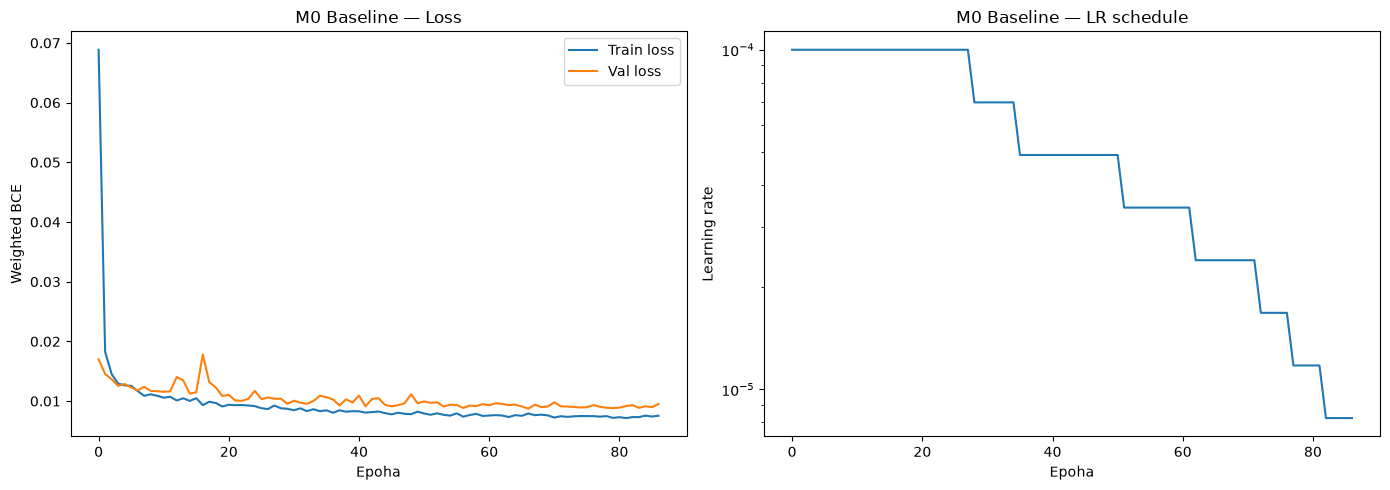

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = metrics["epoch"]

# Loss
axes[0].plot(epochs, metrics["train_loss"], label="Train loss")
axes[0].plot(epochs, metrics["val_loss"],   label="Val loss")
axes[0].set_xlabel("Epoha")
axes[0].set_ylabel("Weighted BCE")
axes[0].set_title("M0 Baseline — Loss")
axes[0].legend()

# Learning rate
axes[1].plot(epochs, metrics["lr"])
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Learning rate")
axes[1].set_title("M0 Baseline — LR schedule")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 5. Threshold tuning na validaciji

Najbolji threshold: 0.65 (piksel F1 = 0.6761)


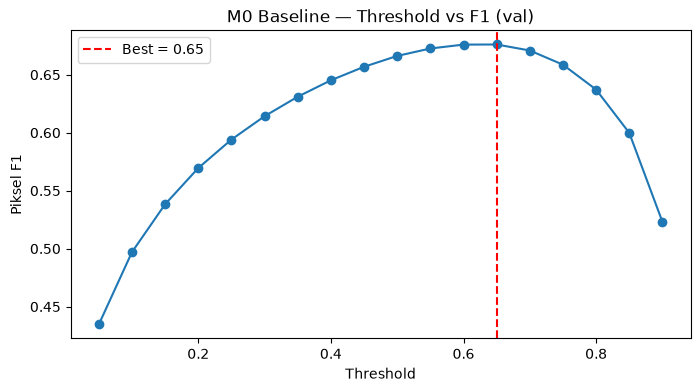

In [11]:
best_thresh, thresh_results = find_best_threshold(model, val_loader, device=device)

ts, f1s = zip(*thresh_results)
plt.figure(figsize=(8, 4))
plt.plot(ts, f1s, marker='o')
plt.axvline(best_thresh, color='r', linestyle='--', label=f'Best = {best_thresh:.2f}')
plt.xlabel("Threshold")
plt.ylabel("Piksel F1")
plt.title("M0 Baseline — Threshold vs F1 (val)")
plt.legend()
plt.show()

## 6. Čuvanje modela i predikcija

In [12]:
MODEL_NAME = "M0_baseline"

save_model(model, MODEL_NAME, best_thresh)
save_predictions(model, test_loader, MODEL_NAME, device=device)

Model sačuvan: /Users/ana_velimirovic/Desktop/Ana-priv/ML/projekat/Fluorescent-neuronal-cell-counting/models/M0_baseline.pth (threshold=0.6500)


Predikcije:   0%|          | 0/70 [00:00<?, ?it/s]

Predikcije sačuvane u /Users/ana_velimirovic/Desktop/Ana-priv/ML/projekat/Fluorescent-neuronal-cell-counting/preds/M0_baseline (70 slika)


## 7. Kvalitativni pregled (par test heatmapa)

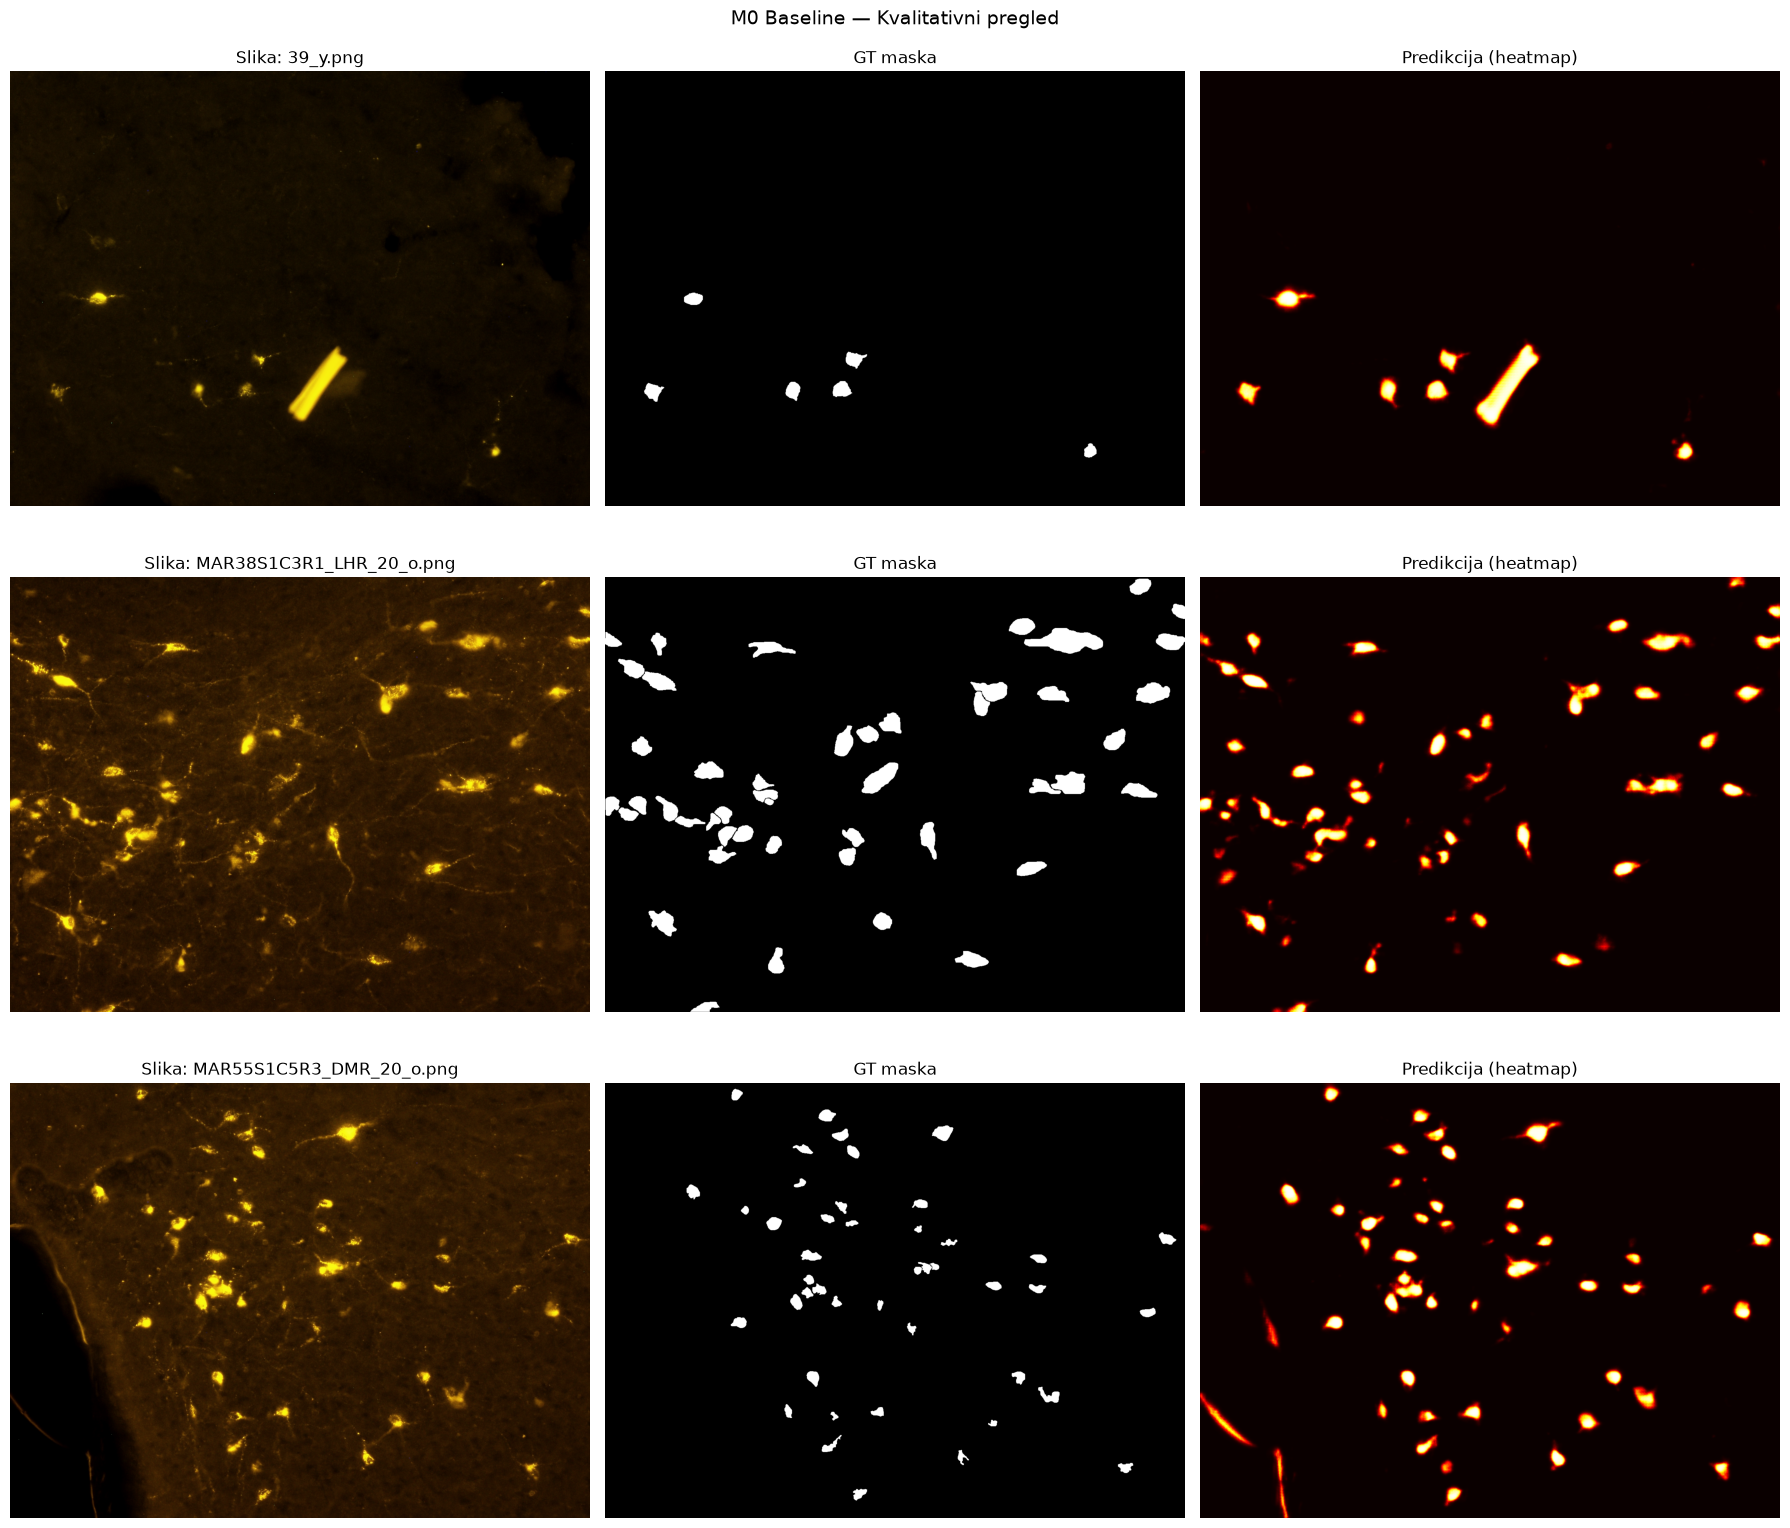

In [13]:
import torch

model.eval()
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

sample_iter = iter(test_loader)
for row in range(3):
    img, mask, iid = next(sample_iter)
    with torch.no_grad():
        pred = model(img.to(device)).cpu()

    # slika
    axes[row, 0].imshow(img[0].permute(1, 2, 0).numpy())
    axes[row, 0].set_title(f"Slika: {iid[0]}")

    # GT maska
    axes[row, 1].imshow(mask[0, 0].numpy(), cmap="gray")
    axes[row, 1].set_title("GT maska")

    # predikcija (heatmap)
    axes[row, 2].imshow(pred[0, 0].numpy(), cmap="hot", vmin=0, vmax=1)
    axes[row, 2].set_title(f"Predikcija (heatmap)")

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("M0 Baseline — Kvalitativni pregled", fontsize=14)
plt.tight_layout()
plt.show()